 Import Libraries

In [1]:
# Cell 1: Import Libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
import dlib
import urllib.request
import os
from scipy.spatial import distance as dist

print("="*50)
print("📊 PHASE 3: FATIGUE DETECTION")
print("="*50)
print(f"✅ OpenCV version: {cv2.__version__}")
print(f"✅ dlib version: {dlib.__version__}")
print("✅ All imports successful!")

📊 PHASE 3: FATIGUE DETECTION
✅ OpenCV version: 4.8.1
✅ dlib version: 20.0.1
✅ All imports successful!


Load Face Detector and Landmark Predictor

In [2]:
# Cell 2: Load Face Detector and Predictor
print("\n📥 Loading face detector and landmark predictor...")

# Face detector
detector = dlib.get_frontal_face_detector()

# Landmark predictor (download if not exists)
landmark_url = "http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2"
landmark_file = "shape_predictor_68_face_landmarks.dat"

if not os.path.exists(landmark_file):
    print("📥 Downloading landmark model (this may take a moment)...")
    import bz2
    urllib.request.urlretrieve(landmark_url, landmark_file + ".bz2")
    
    # Extract
    with open(landmark_file + ".bz2", 'rb') as f:
        data = bz2.decompress(f.read())
    with open(landmark_file, 'wb') as f:
        f.write(data)
    os.remove(landmark_file + ".bz2")
    print("✅ Landmark model downloaded and extracted!")

predictor = dlib.shape_predictor(landmark_file)

print(f"✅ Face detector loaded: {detector is not None}")
print(f"✅ Predictor loaded: {predictor is not None}")


📥 Loading face detector and landmark predictor...
✅ Face detector loaded: True
✅ Predictor loaded: True


Load Sample Face Image


📥 Loading sample face image...
✅ Image already exists!
📊 Image shape: (512, 512, 3)


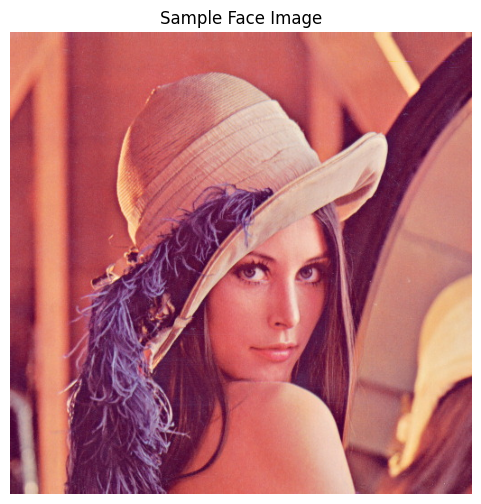

In [3]:
# Cell 3: Load Sample Face Image
print("\n📥 Loading sample face image...")

url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg"
filename = "lena.jpg"

if not os.path.exists(filename):
    urllib.request.urlretrieve(url, filename)
    print("✅ Image downloaded!")
else:
    print("✅ Image already exists!")

# Load image
img = cv2.imread(filename)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

print(f"📊 Image shape: {img.shape}")

# Display
plt.figure(figsize=(6, 6))
plt.imshow(img_rgb)
plt.title("Sample Face Image")
plt.axis('off')
plt.show()

Define Eye Aspect Ratio (EAR) Function

In [4]:
# Cell 4: Eye Aspect Ratio (EAR) Function
print("\n📐 Defining Eye Aspect Ratio (EAR) function...")

def eye_aspect_ratio(eye_points):
    """
    Calculate the Eye Aspect Ratio (EAR) for a given eye.
    
    EAR = (||p2-p6|| + ||p3-p5||) / (2 * ||p1-p4||)
    
    Where:
    - p1: Left corner of eye (point 0)
    - p2: Upper left (point 1)
    - p3: Upper right (point 2)
    - p4: Right corner (point 3)
    - p5: Lower right (point 4)
    - p6: Lower left (point 5)
    """
    # Compute the euclidean distances
    A = dist.euclidean(eye_points[1], eye_points[5])
    B = dist.euclidean(eye_points[2], eye_points[4])
    C = dist.euclidean(eye_points[0], eye_points[3])
    
    # Compute the eye aspect ratio
    ear = (A + B) / (2.0 * C)
    return ear

print("✅ EAR function defined!")
print("📐 EAR = (A + B) / (2 * C)")
print("   - A: Distance between upper/lower left")
print("   - B: Distance between upper/lower right")
print("   - C: Distance between left/right corners")


📐 Defining Eye Aspect Ratio (EAR) function...
✅ EAR function defined!
📐 EAR = (A + B) / (2 * C)
   - A: Distance between upper/lower left
   - B: Distance between upper/lower right
   - C: Distance between left/right corners


Extract Landmarks and Calculate EAR



🔍 Detecting face and extracting landmarks...
✅ Found 1 face(s)

📊 Eye Aspect Ratio Results:
   Left Eye EAR:  0.4050
   Right Eye EAR: 0.5382
   Average EAR:   0.4716

📌 EAR Threshold: 0.25
   ✅ Eyes open - Normal


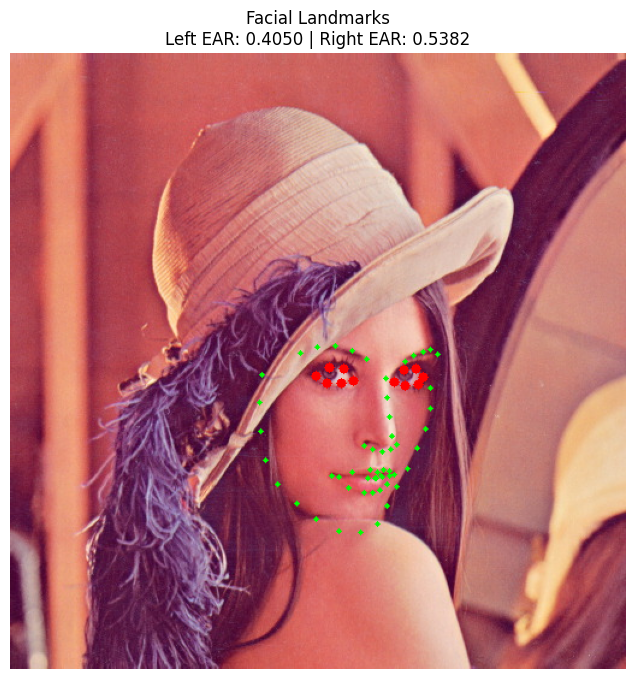

In [5]:
# Cell 5: Extract Landmarks and Calculate EAR
print("\n🔍 Detecting face and extracting landmarks...")

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Detect face
faces = detector(gray)

if len(faces) > 0:
    print(f"✅ Found {len(faces)} face(s)")
    
    # Get landmarks for first face
    face = faces[0]
    landmarks = predictor(gray, face)
    
    # Define eye landmark indices
    # Left eye: points 36-41
    # Right eye: points 42-47
    LEFT_EYE_START = 36
    LEFT_EYE_END = 41
    RIGHT_EYE_START = 42
    RIGHT_EYE_END = 47
    
    # Extract eye coordinates
    left_eye_points = []
    right_eye_points = []
    
    for i in range(LEFT_EYE_START, LEFT_EYE_END + 1):
        x = landmarks.part(i).x
        y = landmarks.part(i).y
        left_eye_points.append((x, y))
    
    for i in range(RIGHT_EYE_START, RIGHT_EYE_END + 1):
        x = landmarks.part(i).x
        y = landmarks.part(i).y
        right_eye_points.append((x, y))
    
    # Calculate EAR for both eyes
    left_ear = eye_aspect_ratio(left_eye_points)
    right_ear = eye_aspect_ratio(right_eye_points)
    avg_ear = (left_ear + right_ear) / 2.0
    
    print(f"\n📊 Eye Aspect Ratio Results:")
    print(f"   Left Eye EAR:  {left_ear:.4f}")
    print(f"   Right Eye EAR: {right_ear:.4f}")
    print(f"   Average EAR:   {avg_ear:.4f}")
    
    # EAR Threshold (below this = eye closed)
    EAR_THRESHOLD = 0.25
    print(f"\n📌 EAR Threshold: {EAR_THRESHOLD}")
    
    if avg_ear < EAR_THRESHOLD:
        print("   ⚠️ EYES CLOSED - Potential Fatigue!")
    else:
        print("   ✅ Eyes open - Normal")
    
    # Draw landmarks
    img_landmarks = img.copy()
    
    # Draw all 68 landmarks
    for i in range(68):
        x = landmarks.part(i).x
        y = landmarks.part(i).y
        cv2.circle(img_landmarks, (x, y), 2, (0, 255, 0), -1)
    
    # Draw eye points in color
    for (x, y) in left_eye_points:
        cv2.circle(img_landmarks, (x, y), 4, (0, 0, 255), -1)
    for (x, y) in right_eye_points:
        cv2.circle(img_landmarks, (x, y), 4, (0, 0, 255), -1)
    
    # Display
    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(img_landmarks, cv2.COLOR_BGR2RGB))
    plt.title(f"Facial Landmarks\nLeft EAR: {left_ear:.4f} | Right EAR: {right_ear:.4f}")
    plt.axis('off')
    plt.show()
    
else:
    print("⚠️ No face detected!")

Create EAR Visualization


📊 Creating EAR visualization...


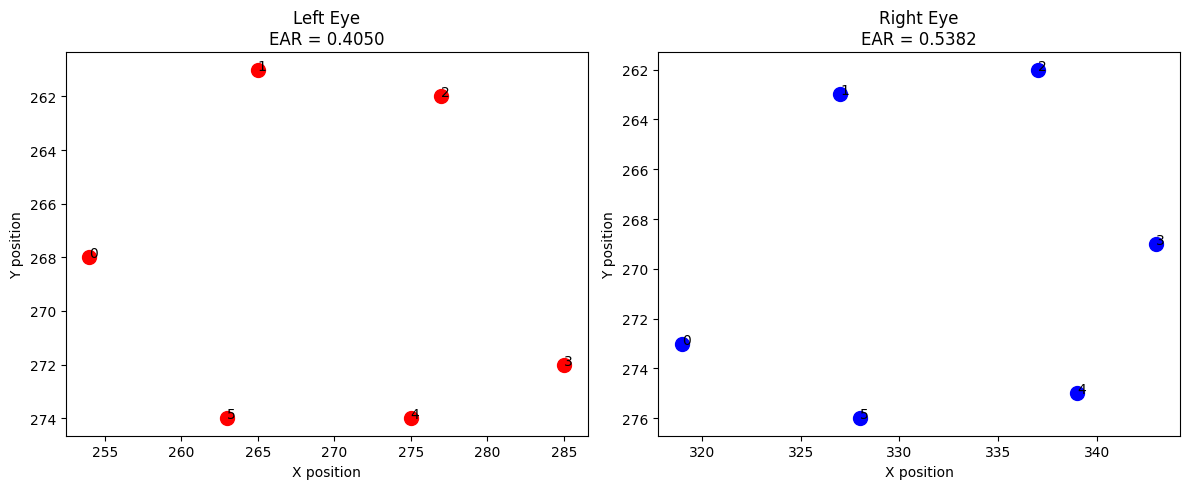


📐 EAR Formula:
   EAR = (A + B) / (2 * C)

   Left Eye:
   - A = 13.15
   - B = 12.17
   - C = 31.26
   - EAR = 0.4050


In [6]:
# Cell 6: EAR Visualization
print("\n📊 Creating EAR visualization...")

# Create a figure showing eye points
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left eye
left_eye_x = [p[0] for p in left_eye_points]
left_eye_y = [p[1] for p in left_eye_points]

axes[0].scatter(left_eye_x, left_eye_y, c='red', s=100)
for i, (x, y) in enumerate(left_eye_points):
    axes[0].annotate(str(i), (x, y), fontsize=10)
axes[0].set_title(f'Left Eye\nEAR = {left_ear:.4f}')
axes[0].set_xlabel('X position')
axes[0].set_ylabel('Y position')
axes[0].invert_yaxis()

# Right eye
right_eye_x = [p[0] for p in right_eye_points]
right_eye_y = [p[1] for p in right_eye_points]

axes[1].scatter(right_eye_x, right_eye_y, c='blue', s=100)
for i, (x, y) in enumerate(right_eye_points):
    axes[1].annotate(str(i), (x, y), fontsize=10)
axes[1].set_title(f'Right Eye\nEAR = {right_ear:.4f}')
axes[1].set_xlabel('X position')
axes[1].set_ylabel('Y position')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("\n📐 EAR Formula:")
print("   EAR = (A + B) / (2 * C)")
print(f"\n   Left Eye:")
print(f"   - A = {dist.euclidean(left_eye_points[1], left_eye_points[5]):.2f}")
print(f"   - B = {dist.euclidean(left_eye_points[2], left_eye_points[4]):.2f}")
print(f"   - C = {dist.euclidean(left_eye_points[0], left_eye_points[3]):.2f}")
print(f"   - EAR = {left_ear:.4f}")

Fatigue Detection Summary

In [7]:
# Cell 7: Phase 3 Summary
print("\n" + "="*50)
print("📊 PHASE 3: FATIGUE DETECTION - SUMMARY")
print("="*50)

print("\n✅ What we learned:")
print("   1. Eye Aspect Ratio (EAR) calculation")
print("   2. Left and right eye extraction")
print("   3. Fatigue detection using EAR threshold")
print("   4. Real-time eye tracking concepts")

print("\n📊 Results:")
print(f"   Left Eye EAR:  {left_ear:.4f}")
print(f"   Right Eye EAR: {right_ear:.4f}")
print(f"   Average EAR:   {avg_ear:.4f}")
print(f"   Threshold:     {EAR_THRESHOLD}")
print(f"   Status:        {'⚠️ FATIGUE' if avg_ear < EAR_THRESHOLD else '✅ Normal'}")

print("\n📚 Key Concepts:")
print("   - EAR = (A + B) / (2 * C)")
print("   - EAR < 0.25 = Eye closed (fatigue)")
print("   - EAR > 0.25 = Eye open (normal)")
print("   - Average of both eyes for accuracy")

print("\n🚀 Next: Phase 4 - Behavior Analysis!")
print("   - Speeding detection")
print("   - Harsh braking detection")
print("   - Driver scorecards")


📊 PHASE 3: FATIGUE DETECTION - SUMMARY

✅ What we learned:
   1. Eye Aspect Ratio (EAR) calculation
   2. Left and right eye extraction
   3. Fatigue detection using EAR threshold
   4. Real-time eye tracking concepts

📊 Results:
   Left Eye EAR:  0.4050
   Right Eye EAR: 0.5382
   Average EAR:   0.4716
   Threshold:     0.25
   Status:        ✅ Normal

📚 Key Concepts:
   - EAR = (A + B) / (2 * C)
   - EAR < 0.25 = Eye closed (fatigue)
   - EAR > 0.25 = Eye open (normal)
   - Average of both eyes for accuracy

🚀 Next: Phase 4 - Behavior Analysis!
   - Speeding detection
   - Harsh braking detection
   - Driver scorecards
